# Paso 01 -- Escalon 1: verificacion a ojo, metricas detalladas, inspector

Corre el entorno (`SimuladorBarcosBergen`, modelo de colas por par
origen-destino -- viajes directos punto a punto, ver `simulacion/README.md`)
con la politica de referencia ("nearest-available", `politica_base.py`)
sobre la franja manana (2 barcos, ~23 grupos / 202 personas,
`output/grupos_escalon1.csv` del paso 00).

Contenido: corrida + log de texto, verificacion de conservacion de personas,
metricas detalladas (por par, globales, por barco, por usuario, perdidas,
desglose de recompensa), graficas, animacion, e inspector de un minuto
concreto.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

BASE_DIR = Path.cwd().parent
BB_DIR = (BASE_DIR / "../bergen-boats").resolve()
sys.path.insert(0, str(BASE_DIR / "src"))

from env import SimuladorBarcosBergen
from politica_base import politica_base, asignar_flota
import metricas as met
import visualizacion as viz

cfg_sim = yaml.safe_load(open(BASE_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_bb = yaml.safe_load(open(BB_DIR / "config" / "instance.yaml", encoding="utf-8"))

nodos = [n["id"] for n in cfg_bb["nodos_demanda"]]
matriz_tiempos = pd.read_csv(BB_DIR / "02_ruteo_navegable" / "output" / "matriz_tiempos_min.csv", index_col=0)
grupos_escalon1 = pd.read_csv(BASE_DIR / "output" / "grupos_escalon1.csv")

cfg_escalon = cfg_sim["escalones"]["escalon_1"]
hora_ini_min, hora_fin_min = cfg_escalon["horas"][0] * 60, cfg_escalon["horas"][1] * 60


def construir_env():
    return SimuladorBarcosBergen(
        grupos_df=grupos_escalon1, matriz_tiempos=matriz_tiempos, nodos=nodos,
        num_barcos=cfg_escalon["num_barcos"], capacidad_barco=cfg_bb["flota"]["capacidad_pasajeros"],
        nodo_inicial=cfg_bb["flota"]["nodo_inicial"], paso_tiempo_min=cfg_sim["paso_tiempo_min"],
        hora_inicio_min=hora_ini_min, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_sim["recompensa"], unidad_demanda=cfg_sim["unidad_demanda"],
    )


print("Nodos:", nodos)
print(f"Barcos: {cfg_escalon['num_barcos']}, capacidad: {cfg_bb['flota']['capacidad_pasajeros']}")
print(f"Horizonte: {hora_ini_min}-{hora_fin_min} min, paso: {cfg_sim['paso_tiempo_min']} min -> {int((hora_fin_min-hora_ini_min)/cfg_sim['paso_tiempo_min'])} pasos")


Nodos: ['kleppesto', 'laksevag', 'bryggen', 'sandviken']
Barcos: 2, capacidad: 20
Horizonte: 360-540 min, paso: 2 min -> 90 pasos


## Corrida completa, con log de texto paso a paso

In [2]:
def resumir_paso(info, r):
    d = info["estado_dict"]
    barcos_str = " | ".join(
        f"{b['origen']}" + (f"->{b['destino']}({b['min_para_llegar']:.0f}m)" if not b['libre'] else "") + f":{b['ocupacion']}p"
        for b in d["barcos"]
    )
    esperando = sum(v["personas"] for v in d["demanda"].values())
    return f"t={d['tiempo']['minuto_del_dia']:4.0f}  r={r:8.3f}  perdidos={info['unidades_perdidas_este_paso']}  mov={info['movimientos_iniciados']}  esperando={esperando:3d}  barcos: {barcos_str}"


env = construir_env()
obs, info = env.reset(seed=cfg_sim["semilla"])
log = []
reward_total = 0.0

while True:
    estado = info["_estado_obj"]
    libres = [b for b in estado.barcos if b.libre]
    decisiones = asignar_flota(libres, estado, matriz_tiempos, env.capacidad_barco, cfg_sim["recompensa"])
    accion = np.array([
        env.codificar_accion_barco(decisiones[b.id]) if b.libre else 0
        for b in estado.barcos
    ])
    obs, r, terminated, truncated, info = env.step(accion)
    reward_total += r
    log.append(resumir_paso(info, r))
    if truncated or terminated:
        break

print(f"{len(log)} pasos simulados. Recompensa total: {reward_total:.2f}\n")
print("\n".join(log))


90 pasos simulados. Recompensa total: -3080.53

t= 362  r=  -0.000  perdidos=0  mov=0  esperando=  0  barcos: B:0p | B:0p
t= 364  r=  -0.000  perdidos=0  mov=0  esperando=  0  barcos: B:0p | B:0p
t= 366  r=  -0.000  perdidos=0  mov=0  esperando=  0  barcos: B:0p | B:0p
t= 368  r=  -0.000  perdidos=0  mov=0  esperando= 10  barcos: B:0p | B:0p
t= 370  r=  -0.200  perdidos=0  mov=2  esperando= 19  barcos: B->L(7m):0p | B->L(7m):0p
t= 372  r=  -0.200  perdidos=0  mov=0  esperando= 19  barcos: B->L(5m):0p | B->L(5m):0p
t= 374  r=  -0.200  perdidos=0  mov=0  esperando= 19  barcos: B->L(3m):0p | B->L(3m):0p
t= 376  r=  -0.200  perdidos=0  mov=0  esperando= 19  barcos: B->L(1m):0p | B->L(1m):0p
t= 378  r=  -0.000  perdidos=0  mov=0  esperando= 19  barcos: L:0p | L:0p
t= 380  r= -12.869  perdidos=0  mov=1  esperando=  6  barcos: L->B(7m):19p | L:0p
t= 382  r= -99.969  perdidos=0  mov=1  esperando=  6  barcos: L->B(5m):19p | L->S(7m):0p
t= 384  r=-272.419  perdidos=0  mov=0  esperando=  6  barco

## Verificacion de conservacion de personas

In [3]:
conservacion = met.verificar_conservacion(env)
for k, v in conservacion.items():
    print(f"{k}: {v}")
assert conservacion["cuadra"], "La conservacion de personas no cuadra -- hay un bug que exponer, no esconder."
print("\nOK: todas las personas generadas quedaron contabilizadas (atendidas + perdidas + esperando + a bordo).")


generadas: 202


atendidas: 181
perdidas: 21
esperando_al_final: 0
a_bordo_al_final: 0
suma: 202
cuadra: True

OK: todas las personas generadas quedaron contabilizadas (atendidas + perdidas + esperando + a bordo).


## Metricas detalladas

In [4]:
reporte = met.reporte_completo(env)

print("=== Globales ===")
for k, v in reporte["globales"].items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

print("\n=== Por par (solo pares con demanda) ===")
df_par = reporte["por_par"]
display(df_par[df_par["generadas"] > 0].round(1))


=== Globales ===
  unidades_generadas: 202
  unidades_atendidas: 181
  unidades_perdidas: 21
  pct_cumplimiento_global: 89.60
  espera_media_min: 10.67
  sistema_medio_min: 19.53
  sistema_maximo_min: 34.02

=== Por par (solo pares con demanda) ===


,par,generadas,atendidas,perdidas,pct_cumplimiento,espera_media_min,espera_maxima_min,viaje_medio_min,sistema_medio_min,sistema_maximo_min
0,kleppesto->laksevag,30,30,0,100.0,17.2,24.5,6.0,23.2,30.5
1,kleppesto->bryggen,55,55,0,100.0,11.0,18.1,12.0,23.0,30.1
2,kleppesto->sandviken,7,7,0,100.0,0.8,0.8,10.0,10.8,10.8
4,laksevag->bryggen,47,47,0,100.0,8.4,13.9,10.0,18.4,23.9
6,bryggen->kleppesto,11,11,0,100.0,7.6,7.6,12.0,19.6,19.6
7,bryggen->laksevag,16,7,9,43.8,7.4,12.3,10.0,11.8,12.3
9,sandviken->kleppesto,7,7,0,100.0,24.0,24.0,10.0,34.0,34.0
11,sandviken->bryggen,29,17,12,58.6,9.1,15.0,8.0,13.8,19.6


In [5]:
print("=== Por barco ===")
display(reporte["por_barco"].round(1))

print("\n=== Por usuario (percentiles, minutos) ===")
for k, v in reporte["por_usuario"].items():
    print(f"  {k}: {v}")

print("\n=== Perdidas por par ===")
display(reporte["perdidas_por_nodo"])

reporte["por_par"].to_csv(BASE_DIR / "output" / "metricas_por_par_escalon1.csv", index=False)
reporte["por_barco"].to_csv(BASE_DIR / "output" / "metricas_por_barco_escalon1.csv", index=False)


=== Por barco ===


,barco_id,movimientos,tiempo_navegado_min,ocupacion_media,ocupacion_maxima,pct_ocioso,ruta_mas_frecuente
0,barco_0,13,102,4.5,20,44.0,bryggen->kleppesto (3x)
1,barco_1,14,106,3.4,18,41.8,bryggen->laksevag (3x)



=== Por usuario (percentiles, minutos) ===
  espera_min: {'p50': 11.129999999999995, 'p90': 18.100000000000023, 'p95': 24.019999999999982, 'max': 24.480000000000018}
  viaje_min: {'p50': 10.0, 'p90': 12.0, 'p95': 12.0, 'max': 12.0}
  sistema_min: {'p50': 19.620000000000005, 'p90': 30.100000000000023, 'p95': 30.480000000000018, 'max': 34.01999999999998}

=== Perdidas por par ===


,par,perdidas
1,sandviken->bryggen,12
0,bryggen->laksevag,9


## Graficas

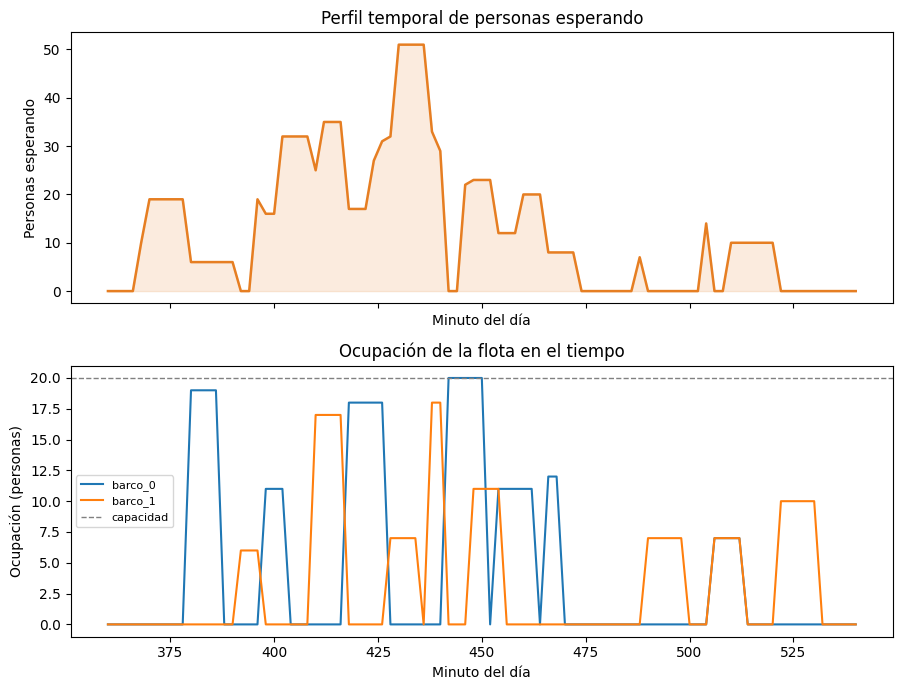

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
viz.graficar_perfil_espera(env, ax=axs[0])
viz.graficar_ocupacion_flota(env, ax=axs[1])
fig.tight_layout()
fig.savefig(BASE_DIR / "output" / "escalon1_perfil_y_ocupacion.png", dpi=150)
plt.show()


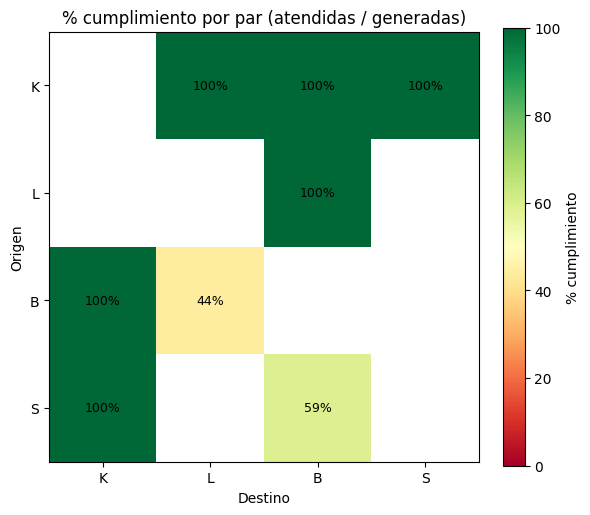

In [7]:
fig, ax = plt.subplots(figsize=(6, 5.5))
viz.graficar_heatmap_cumplimiento(env, ax=ax)
fig.tight_layout()
fig.savefig(BASE_DIR / "output" / "escalon1_heatmap_cumplimiento.png", dpi=150)
plt.show()


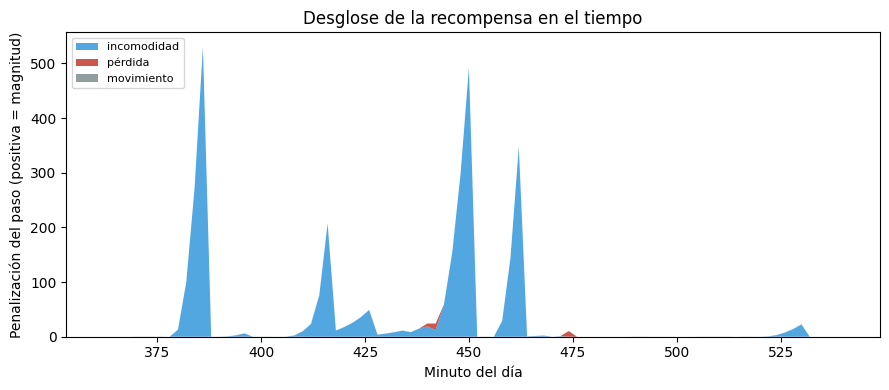

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
viz.graficar_desglose_recompensa(env, ax=ax)
fig.tight_layout()
fig.savefig(BASE_DIR / "output" / "escalon1_desglose_recompensa.png", dpi=150)
plt.show()


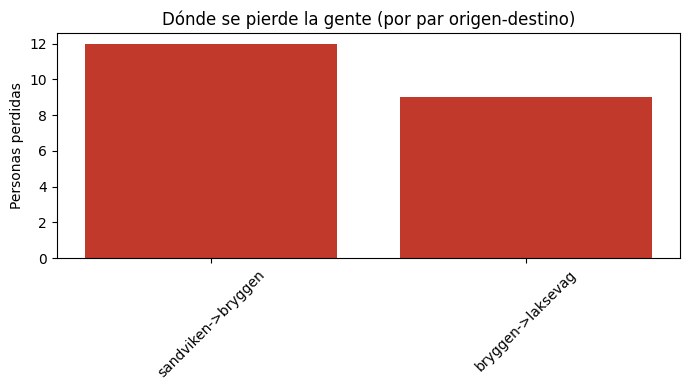

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
viz.graficar_perdidas_por_nodo(env, ax=ax)
fig.tight_layout()
fig.savefig(BASE_DIR / "output" / "escalon1_perdidas_por_nodo.png", dpi=150)
plt.show()


## Visualizacion: mapa real + rutas navegables + barcos en movimiento

Reusa el mapa base y `bergen-boats/02_ruteo_navegable/output/rutas_navegables.geojson`
(persistidas en este mismo trabajo) para que los barcos se muevan bordeando
tierra, no en linea recta. El historial completo de la corrida ya vive en
`env.historial_estados` (lo registra el propio entorno, no hace falta
juntarlo a mano en el bucle de arriba).


In [10]:
gdf_nodos, gdf_rutas = viz.cargar_capas_mapa(cfg_bb, BB_DIR / "02_ruteo_navegable" / "output" / "rutas_navegables.geojson")

out_gif = BASE_DIR / "output" / "escalon1_animacion.gif"
viz.animar_corrida(env.historial_estados, gdf_nodos, gdf_rutas, matriz_tiempos, env.capacidad_barco, out_gif, fps=6)
print("Guardado:", out_gif)


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\simulacion\output\escalon1_animacion.gif


## Inspector: pausar en un minuto concreto

`inspeccionar(minuto, ...)` funciona siempre (no requiere kernel vivo).
`inspeccionar_interactivo(...)` agrega un slider real de `ipywidgets`, pero
SOLO funciona si este notebook se abre con un kernel de Jupyter corriendo
(VS Code / Jupyter Lab) -- un notebook ya ejecutado y guardado no tiene
kernel vivo, asi que aqui abajo se muestra el uso directo con numeros.


=== Minuto 400 ===
Barcos:
  barco_0: S->B (3 min), ocupación=11
  barco_1: B->L (7 min), ocupación=0
Colas (pares con gente esperando):
  K->B: 8 personas, la más antigua lleva 2.1 min
  L->B: 8 personas, la más antigua lleva 5.9 min
Recompensa del paso: -0.200 (incomodidad=0.000, perdida=0.000, movimiento=0.200)


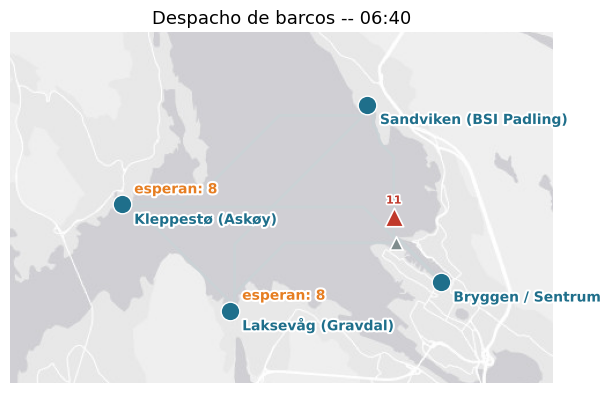

In [11]:
fondo = viz.descargar_fondo_mapa(gdf_nodos)
fig = viz.inspeccionar(400, env, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo)
fig.savefig(BASE_DIR / "output" / "escalon1_inspeccion_minuto400.png", dpi=150, bbox_inches="tight")
plt.show()


=== Minuto 420 ===
Barcos:
  barco_0: K->B (8 min), ocupación=18
  barco_1: B->S (5 min), ocupación=0
Colas (pares con gente esperando):
  K->L: 10 personas, la más antigua lleva 8.5 min
  S->K: 7 personas, la más antigua lleva 18.0 min
Recompensa del paso: -17.833 (incomodidad=17.633, perdida=0.000, movimiento=0.200)


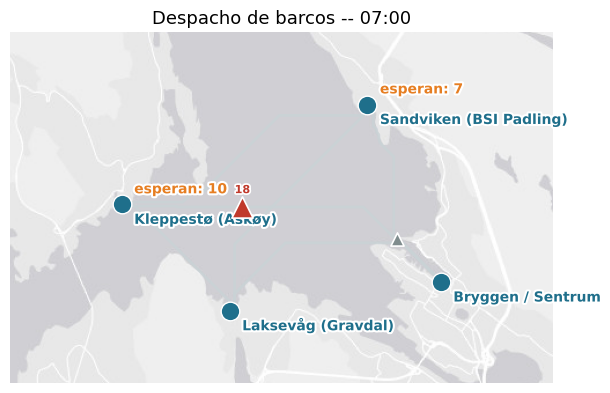

In [12]:
fig = viz.inspeccionar(420, env, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo)
plt.show()


## Verificacion de reproducibilidad

In [13]:
sys.path.insert(0, str((BASE_DIR / "../demand/src").resolve()))
import llegadas as demand_llegadas
import masas as demand_masas

DEMAND_DIR = (BASE_DIR / "../demand").resolve()
cfg_demand = demand_masas.cargar_config(DEMAND_DIR / "config" / "instance.yaml")
resumen_masas = pd.read_csv(DEMAND_DIR / "output" / "masas_por_nodo.csv", index_col="id")
intensidad_od = pd.read_csv(DEMAND_DIR / "output" / "matriz_intensidad_od.csv")
poblacion_total_zonas = resumen_masas["poblacion_total"].sum()
bb_cfg_path2 = (DEMAND_DIR / cfg_demand["fuentes_externas"]["nodos_config"]).resolve()
cfg_bb2 = yaml.safe_load(open(bb_cfg_path2, encoding="utf-8"))
conexiones_fuertes = cfg_bb2["garantia"]["conexiones_fuertes"]


def generar_grupos_con_semilla(semilla):
    cfg_mod = dict(cfg_demand)
    cfg_mod["demanda"] = dict(cfg_demand["demanda"])
    cfg_mod["demanda"]["porcentaje_poblacion_dia"] = cfg_escalon["porcentaje_poblacion_dia"]
    rng = np.random.default_rng(semilla)
    grupos = demand_llegadas.generar_llegadas_dia(
        cfg_mod, intensidad_od, conexiones_fuertes, poblacion_total_zonas,
        es_fin_de_semana=False, rng=rng, dia_id="repro",
    )
    hora_ini, hora_fin = cfg_escalon["horas"]
    return grupos[(grupos["hora"] >= hora_ini) & (grupos["hora"] < hora_fin)].reset_index(drop=True)


def correr_una_vez(grupos_df):
    env2 = SimuladorBarcosBergen(
        grupos_df=grupos_df, matriz_tiempos=matriz_tiempos, nodos=nodos,
        num_barcos=cfg_escalon["num_barcos"], capacidad_barco=cfg_bb["flota"]["capacidad_pasajeros"],
        nodo_inicial=cfg_bb["flota"]["nodo_inicial"], paso_tiempo_min=cfg_sim["paso_tiempo_min"],
        hora_inicio_min=hora_ini_min, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_sim["recompensa"], unidad_demanda=cfg_sim["unidad_demanda"],
    )
    obs, info = env2.reset(seed=cfg_sim["semilla"])
    total = 0.0
    while True:
        estado = info["_estado_obj"]
        libres = [b for b in estado.barcos if b.libre]
        decisiones = asignar_flota(libres, estado, matriz_tiempos, env2.capacidad_barco, cfg_sim["recompensa"])
        accion = np.array([
            env2.codificar_accion_barco(decisiones[b.id]) if b.libre else 0
            for b in estado.barcos
        ])
        obs, r, terminated, truncated, info = env2.step(accion)
        total += r
        if truncated or terminated:
            break
    return round(total, 6), len(env2.atendidas_historico), len(env2.perdidas_historico)


grupos_semilla_42_a = generar_grupos_con_semilla(42)
grupos_semilla_42_b = generar_grupos_con_semilla(42)
grupos_semilla_43 = generar_grupos_con_semilla(43)

r1 = correr_una_vez(grupos_semilla_42_a)
r2 = correr_una_vez(grupos_semilla_42_b)
r3 = correr_una_vez(grupos_semilla_43)
print("Semilla 42, generacion a:", r1)
print("Semilla 42, generacion b:", r2)
print("Semilla 43:              ", r3)
print("Misma semilla de demanda -> misma corrida completa:", r1 == r2)
print("Semilla distinta -> corrida distinta:", r1 != r3)


Semilla 42, generacion a: (-3080.531825, 181, 21)
Semilla 42, generacion b: (-3080.531825, 181, 21)
Semilla 43:               (-1232.609301, 183, 30)
Misma semilla de demanda -> misma corrida completa: True
Semilla distinta -> corrida distinta: True
